In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/yolov8-segmentation/README.dataset.txt
/kaggle/input/yolov8-segmentation/README.roboflow.txt
/kaggle/input/yolov8-segmentation/data.yaml
/kaggle/input/yolov8-segmentation/valid/labels/Te-pi_0162_jpg.rf.9cb448e1f29c3f1d0374706494a03110.txt
/kaggle/input/yolov8-segmentation/valid/labels/Te-gl_0167_jpg.rf.45fd2b60f10accc4f067235d70dc77cc.txt
/kaggle/input/yolov8-segmentation/valid/labels/DICOM-Frame-208_jpg.rf.210adb8dda0b149f435e8c709856d942.txt
/kaggle/input/yolov8-segmentation/valid/labels/Tr-pi_0897_jpg.rf.7c3bbd5463a3af9ed9983f3a69995587.txt
/kaggle/input/yolov8-segmentation/valid/labels/Tr-gl_0239_jpg.rf.ea18c6e82ce8965b833d55bf4c786d8d.txt
/kaggle/input/yolov8-segmentation/valid/labels/m3-82-_jpg.rf.b769dbf18a97fbd82058a670525e9fe3.txt
/kaggle/input/yolov8-segmentation/valid/labels/Tr-gl_0918_jpg.rf.f8fc334dba5f8bffd8b9565ce0d51fb5.txt
/kaggle/input/yolov8-segmentation/valid/labels/gg-353-_jpg.rf.63bce7a608cdbc41f161b0e54b21f2e9.txt
/kaggle/input/yolov8-segmentation/v

In [2]:
# Install Essential Libraries
!pip install ultralytics
from IPython import display
display.clear_output()

In [3]:
# Import Essential Libraries
import os
import pandas as pd
from PIL import Image
import cv2
from ultralytics import YOLO
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
# Load a pretrained YOLOv8n model from Ultralytics
T_Model = YOLO('yolov8n.pt')
T_Model = YOLO('yolov8s-seg.pt')

In [5]:
from ultralytics import YOLO

# Load YOLOv8 segmentation model
model = YOLO("yolov8s-seg.pt")

# Train the model
results = model.train(
    data="/kaggle/input/yolov8-segmentation/data.yaml",
    epochs=50,
    imgsz=768,           
    batch=16,
    patience=20,
    optimizer='auto',
    name="brain_seg_yolov8"
)


Ultralytics 8.3.246 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/yolov8-segmentation/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=brain_seg_yolov8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspe

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

pred_dir = Path("/kaggle/working/runs/segment/predict_from_script")

# only select original prediction images (not batch or random training panels)
image_files = sorted([
    f for f in pred_dir.glob("*.*") 
    if f.suffix.lower() in [".jpg", ".png"]
    and "batch" not in f.name.lower()
    and "labels" not in f.name.lower()
    and "pred" not in f.name.lower()
])[:12]   # show 12 images

rows, cols = 3, 4
plt.figure(figsize=(4*cols, 4*rows))

for i, img_path in enumerate(image_files, start=1):
    img = mpimg.imread(str(img_path))
    plt.subplot(rows, cols, i)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()


<Figure size 1600x1200 with 0 Axes>

In [7]:
for img_path in image_files:
    img = mpimg.imread(str(img_path))
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.name)
    plt.show()


In [8]:
!ls -R /kaggle/working

/kaggle/working:
__notebook__.ipynb  runs  yolo11n.pt  yolov8n.pt  yolov8s-seg.pt

/kaggle/working/runs:
segment

/kaggle/working/runs/segment:
brain_seg_yolov8

/kaggle/working/runs/segment/brain_seg_yolov8:
args.yaml			 MaskP_curve.png      train_batch9361.jpg
BoxF1_curve.png			 MaskPR_curve.png     train_batch9362.jpg
BoxP_curve.png			 MaskR_curve.png      val_batch0_labels.jpg
BoxPR_curve.png			 results.csv	      val_batch0_pred.jpg
BoxR_curve.png			 results.png	      val_batch1_labels.jpg
confusion_matrix_normalized.png  train_batch0.jpg     val_batch1_pred.jpg
confusion_matrix.png		 train_batch1.jpg     val_batch2_labels.jpg
labels.jpg			 train_batch2.jpg     val_batch2_pred.jpg
MaskF1_curve.png		 train_batch9360.jpg  weights

/kaggle/working/runs/segment/brain_seg_yolov8/weights:
best.pt  last.pt


In [9]:
!ls -R /kaggle/input


/kaggle/input:
yolov8-segmentation

/kaggle/input/yolov8-segmentation:
data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid

/kaggle/input/yolov8-segmentation/test:
images	labels

/kaggle/input/yolov8-segmentation/test/images:
DICOM-Frame-132_jpg.rf.0f450296c39e68ceef8020a62236f586.jpg
DICOM-Frame-182_jpg.rf.88f0ce81fd27fbdee357c356dee5c4d7.jpg
DICOM-Frame-222_jpg.rf.23b2ec354c57b816a2503f87b0ba20ae.jpg
DICOM-Frame-242_jpg.rf.0d8a43fb62bdb46dbf25f5aa3e442200.jpg
DICOM-Frame-96_jpg.rf.67ce1570834babf6503fd81b4e7ffdae.jpg
gg-103-_jpg.rf.76928987dcef51e838fea387ef2c291e.jpg
gg-143-_jpg.rf.14e918d8f25256668440d53dbc9dc1c6.jpg
gg-156-_jpg.rf.dec8d411d42c056f267d6d1100f2bfd5.jpg
gg-15-_jpg.rf.a054e7a84cadceff09e91f82aca5a828.jpg
gg-256-_jpg.rf.6489ff0f97a41bd62daf601b709c717d.jpg
gg-310-_jpg.rf.8fc90165f027529002cf54fe444baab7.jpg
gg-34-_jpg.rf.ed486333acffae66740d8bafdb092aa4.jpg
gg-352-_jpg.rf.cdee09a1fdb9842fed71bc9ad24dd2b9.jpg
gg-354-_jpg.rf.3314fb32cfefc02791790ec1aab

In [10]:
from pathlib import Path

# Trained weights
WEIGHTS = Path("/kaggle/working/runs/segment/brain_seg_yolov8/weights/best.pt")

# Original test images
SRC_DIR = "/kaggle/input/yolov8-segmentation/test/images"

print("Using weights:", WEIGHTS)
print("Source images:", SRC_DIR)

# Run segmentation prediction on test set
!yolo segment predict model={WEIGHTS} source={SRC_DIR} save=True name=clean_test_pred


Using weights: /kaggle/working/runs/segment/brain_seg_yolov8/weights/best.pt
Source images: /kaggle/input/yolov8-segmentation/test/images
Ultralytics 8.3.246 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8s-seg summary (fused): 85 layers, 11,780,761 parameters, 0 gradients, 39.9 GFLOPs

image 1/179 /kaggle/input/yolov8-segmentation/test/images/DICOM-Frame-132_jpg.rf.0f450296c39e68ceef8020a62236f586.jpg: 768x768 1 pituitary, 26.5ms
image 2/179 /kaggle/input/yolov8-segmentation/test/images/DICOM-Frame-182_jpg.rf.88f0ce81fd27fbdee357c356dee5c4d7.jpg: 768x768 1 pituitary, 26.4ms
image 3/179 /kaggle/input/yolov8-segmentation/test/images/DICOM-Frame-222_jpg.rf.23b2ec354c57b816a2503f87b0ba20ae.jpg: 768x768 1 pituitary, 26.4ms
image 4/179 /kaggle/input/yolov8-segmentation/test/images/DICOM-Frame-242_jpg.rf.0d8a43fb62bdb46dbf25f5aa3e442200.jpg: 768x768 (no detections), 26.4ms
image 5/179 /kaggle/input/yolov8-segmentation/test/images/DICOM-Frame-96_jpg.rf.67ce1570834babf650

In [11]:
from pathlib import Path

# Trained weights
WEIGHTS = Path("/kaggle/working/runs/segment/brain_seg_yolov8/weights/best.pt")

# Original test images
SRC_DIR = "/kaggle/input/yolov8-segmentation/test/images"

print("Using weights:", WEIGHTS)
print("Source images:", SRC_DIR)

# Run segmentation prediction on test set
!yolo segment predict model={WEIGHTS} source={SRC_DIR} save=True name=clean_test_pred


Using weights: /kaggle/working/runs/segment/brain_seg_yolov8/weights/best.pt
Source images: /kaggle/input/yolov8-segmentation/test/images
Ultralytics 8.3.246 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8s-seg summary (fused): 85 layers, 11,780,761 parameters, 0 gradients, 39.9 GFLOPs

image 1/179 /kaggle/input/yolov8-segmentation/test/images/DICOM-Frame-132_jpg.rf.0f450296c39e68ceef8020a62236f586.jpg: 768x768 1 pituitary, 26.5ms
image 2/179 /kaggle/input/yolov8-segmentation/test/images/DICOM-Frame-182_jpg.rf.88f0ce81fd27fbdee357c356dee5c4d7.jpg: 768x768 1 pituitary, 26.4ms
image 3/179 /kaggle/input/yolov8-segmentation/test/images/DICOM-Frame-222_jpg.rf.23b2ec354c57b816a2503f87b0ba20ae.jpg: 768x768 1 pituitary, 26.4ms
image 4/179 /kaggle/input/yolov8-segmentation/test/images/DICOM-Frame-242_jpg.rf.0d8a43fb62bdb46dbf25f5aa3e442200.jpg: 768x768 (no detections), 26.3ms
image 5/179 /kaggle/input/yolov8-segmentation/test/images/DICOM-Frame-96_jpg.rf.67ce1570834babf650

Using prediction folder: /kaggle/working/runs/segment/clean_test_pred2
[INFO] Showing 12 images


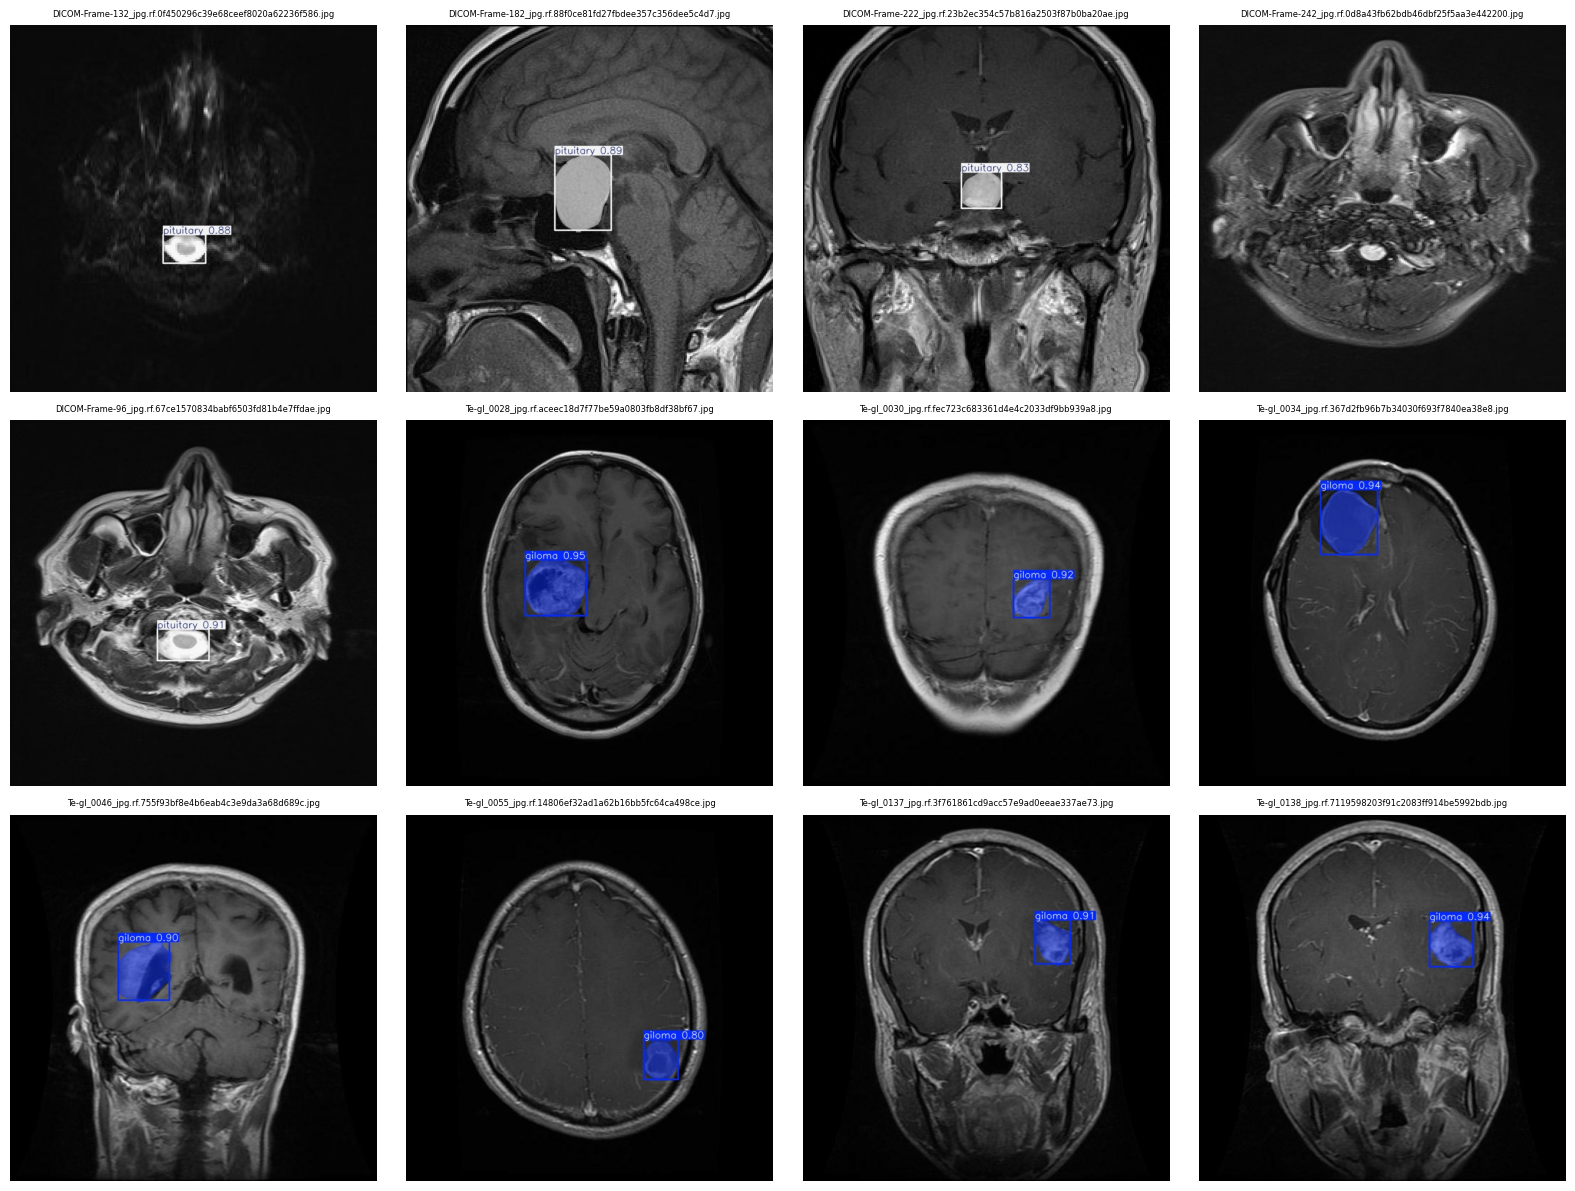

In [12]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Find the latest `clean_test_pred*` folder
segment_root = Path("/kaggle/working/runs/segment")
pred_dirs = sorted(segment_root.glob("clean_test_pred*"))
assert pred_dirs, "No 'clean_test_pred*' folder found. Run the prediction cell first."

pred_dir = pred_dirs[-1]  # take the newest one
print("Using prediction folder:", pred_dir)

# Take the first 12 jpg/png images
image_files = sorted(
    [f for f in pred_dir.glob("*.*") if f.suffix.lower() in [".jpg", ".png"]]
)[:12]

print(f"[INFO] Showing {len(image_files)} images")

rows, cols = 3, 4
plt.figure(figsize=(4 * cols, 4 * rows))

for i, img_path in enumerate(image_files, start=1):
    img = mpimg.imread(str(img_path))
    plt.subplot(rows, cols, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.name, fontsize=6)

plt.tight_layout()
plt.show()


In [13]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

pred_dir = Path("/kaggle/working/runs/segment/predict")
image_files = sorted(list(pred_dir.glob("*.jpg")) + list(pred_dir.glob("*.png")))[:20]

cols, rows = 5, (len(image_files)+4)//5
plt.figure(figsize=(4*cols, 4*rows))
for i, img_path in enumerate(image_files, 1):
    img = mpimg.imread(img_path)
    plt.subplot(rows, cols, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.name, fontsize=8)
plt.tight_layout()
plt.show()


<Figure size 2000x0 with 0 Axes>

In [14]:
# ---- Install Ultralytics (if missing) + OpenCV ----
import sys, importlib, subprocess

def ensure(pkg):
    mod = pkg.split("==")[0].split("[")[0].replace("-", "_")
    try:
        importlib.import_module(mod if mod != "opencv_python_headless" else "cv2")
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

ensure("ultralytics==8.3.189")           # same version as your logs
ensure("opencv-python-headless")         # for cv2 without GUI

from ultralytics import YOLO
import cv2
print("✅ Ready:", YOLO.__name__)


✅ Ready: YOLO


In [15]:
!pip install grad-cam
!pip install torch torchvision


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 67.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=f48c2bec25605a6f2bdc46f510e30788eae84b9b6ff4d3604eabf1caf3e74a9e
  Stored in directory: /root/.cache/pip/wheels/bc/52/78/893c3b94279ef238f43a9e89608af648de401b96415bebbd1f
Successfully built grad-cam


In [16]:
import cv2
import numpy as np

def show_segmentation_explainability(image_path, model, save_path="seg_xai.jpg"):
    # Run the model
    results = model(image_path)[0]
    
    # Read original image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    if results.masks is None:
        print("No masks found.")
        return
    
    masks = results.masks.data.cpu().numpy()
    h, w, _ = img.shape
    
    # Combine all masks into one
    combined_mask = np.zeros((h, w), dtype=np.float32)
    for m in masks:
        m_resized = cv2.resize(m, (w, h))
        combined_mask = np.maximum(combined_mask, m_resized)
    
    combined_mask = (combined_mask > 0.5).astype(np.float32)
    
    # Create heatmap
    heatmap = cv2.applyColorMap((combined_mask * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    # Overlay heatmap on original image
    overlay = (0.5 * heatmap + 0.5 * img).astype(np.uint8)
    
    # Save result
    cv2.imwrite(save_path, cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
    print("Explainability saved to:", save_path)


In [17]:
!pip install YOLOv8-Explainer


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 62.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.4.8-py3-none-any.whl size=38341 sha256=58f41ac8249447eafc323682f4f35ae390204f2a6a47a2c140d7513e2fd958df
  Stored in directory: /root/.cache/pip/wheels/74/49/bf/77ae8f382e1f0057897d00202b6647ec539c995f384f9a8eec
Successfully built grad-cam
  Attempting uninstall: grad-cam
    Found existing installation: grad-cam 1.5.5
    Uninstalling grad-cam-1.5.5:
      Successfully uninstalled grad-cam-1.5.5


In [18]:
!pip install grad-cam


In [19]:
!ls -R /kaggle/working/runs/segment


/kaggle/working/runs/segment:
brain_seg_yolov8  clean_test_pred  clean_test_pred2

/kaggle/working/runs/segment/brain_seg_yolov8:
args.yaml			 MaskP_curve.png      train_batch9361.jpg
BoxF1_curve.png			 MaskPR_curve.png     train_batch9362.jpg
BoxP_curve.png			 MaskR_curve.png      val_batch0_labels.jpg
BoxPR_curve.png			 results.csv	      val_batch0_pred.jpg
BoxR_curve.png			 results.png	      val_batch1_labels.jpg
confusion_matrix_normalized.png  train_batch0.jpg     val_batch1_pred.jpg
confusion_matrix.png		 train_batch1.jpg     val_batch2_labels.jpg
labels.jpg			 train_batch2.jpg     val_batch2_pred.jpg
MaskF1_curve.png		 train_batch9360.jpg  weights

/kaggle/working/runs/segment/brain_seg_yolov8/weights:
best.pt  last.pt

/kaggle/working/runs/segment/clean_test_pred:
DICOM-Frame-132_jpg.rf.0f450296c39e68ceef8020a62236f586.jpg
DICOM-Frame-182_jpg.rf.88f0ce81fd27fbdee357c356dee5c4d7.jpg
DICOM-Frame-222_jpg.rf.23b2ec354c57b816a2503f87b0ba20ae.jpg
DICOM-Frame-242_jpg.rf.0d8a43fb62bdb4

In [20]:
from ultralytics import YOLO
from pathlib import Path
import torch
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import EigenCAM   # you can also use GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# Your trained weights
WEIGHTS = Path("/kaggle/working/runs/segment/brain_seg_yolov8/weights/best.pt")
assert WEIGHTS.exists(), f"Weights not found: {WEIGHTS}"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


In [21]:
# Load YOLOv8-seg model
model = YOLO(str(WEIGHTS))
inner_model = model.model.to(device)
inner_model.eval()

# Helper: get the last Conv2d layer in the network
def get_last_conv_layer(net):
    conv_layers = [m for m in net.modules() if isinstance(m, nn.Conv2d)]
    assert len(conv_layers) > 0, "No Conv2d layers found in model."
    return conv_layers[-1]

target_layer = get_last_conv_layer(inner_model)
target_layers = [target_layer]
print("Using target layer for CAM:", target_layer)


Using target layer for CAM: Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))


In [22]:
# One example test image
img_dir = Path("/kaggle/input/yolov8-segmentation/test/images")
test_images = sorted(list(img_dir.glob("*.jpg")))
assert test_images, "No test images found."

img_path = test_images[0]   # you can change index
print("Explaining image:", img_path.name)

# Read and convert to RGB
bgr = cv2.imread(str(img_path))
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
rgb_float = rgb.astype(np.float32) / 255.0

# To tensor [1, 3, H, W]
input_tensor = (
    torch.from_numpy(rgb_float)
    .permute(2, 0, 1)
    .unsqueeze(0)
    .to(device)
)


Explaining image: DICOM-Frame-132_jpg.rf.0f450296c39e68ceef8020a62236f586.jpg


In [23]:
from ultralytics import YOLO
from pathlib import Path
import torch
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Trained YOLOv8-seg weights
WEIGHTS = Path("/kaggle/working/runs/segment/brain_seg_yolov8/weights/best.pt")
assert WEIGHTS.exists(), f"Weights not found: {WEIGHTS}"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Load model
model = YOLO(str(WEIGHTS))
inner_model = model.model.to(device)
inner_model.eval()


Device: cuda


SegmentationModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(96, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
 

In [24]:
# Collect all Conv2d layers in the network
conv_layers = [m for m in inner_model.modules() if isinstance(m, nn.Conv2d)]
assert conv_layers, "No Conv2d layers found in YOLO model."

last_conv = conv_layers[-1]
print("Using last Conv2d layer for XAI:", last_conv)

# Store feature maps from the hook
feature_maps = {}

def hook_fn(module, input, output):
    # Save activation for later use
    feature_maps["value"] = output.detach()

# Register forward hook on the last conv layer
hook_handle = last_conv.register_forward_hook(hook_fn)


Using last Conv2d layer for XAI: Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))


In [25]:
from pathlib import Path

img_dir = Path("/kaggle/input/yolov8-segmentation/test/images")
test_images = sorted(list(img_dir.glob("*.jpg")))
assert test_images, "No test images found in test/images."

img_path = test_images[0]   # choose any index you like
print("Explaining image:", img_path.name)

# Read image in BGR then convert to RGB
bgr = cv2.imread(str(img_path))
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


Explaining image: DICOM-Frame-132_jpg.rf.0f450296c39e68ceef8020a62236f586.jpg


In [26]:
# Run full YOLO prediction (normal way) – this will trigger our hook
_ = model(str(img_path), verbose=False)

# Get feature map from hooked layer
act = feature_maps.get("value", None)
assert act is not None, "Hook did not capture any activations."

# Take the first image in batch: shape [C, H, W]
act = act[0]   # tensor

print("Activation shape:", act.shape)  # e.g., [C, H, W]


Activation shape: torch.Size([32, 24, 24])


In [27]:
# Mean over channels -> [H, W]
heat = act.mean(dim=0).cpu().numpy()

# Keep only non-negative values (optional but common)
heat = np.maximum(heat, 0)

# Normalize to [0, 1]
heat -= heat.min()
if heat.max() > 0:
    heat /= heat.max()

print("Heatmap min/max:", heat.min(), heat.max())


Heatmap min/max: 0.0 1.0


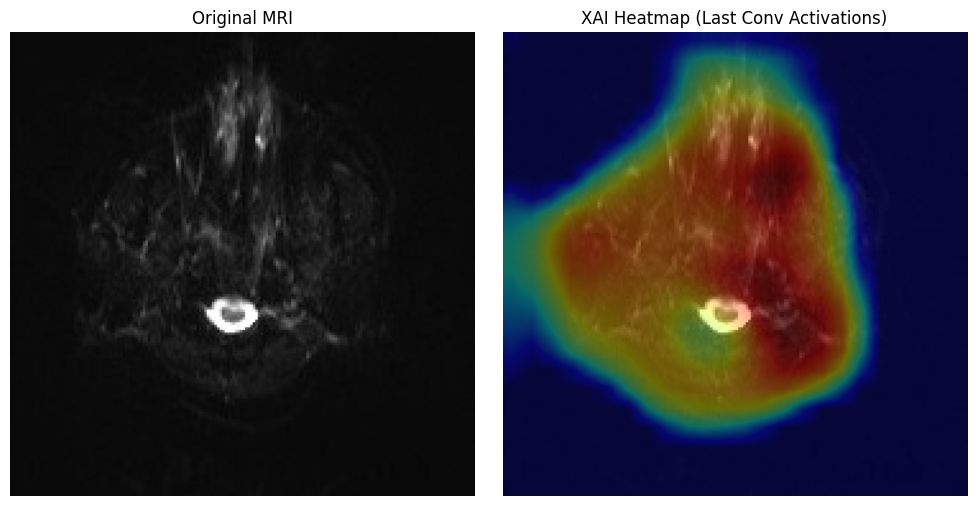

In [28]:
# Resize heatmap to original image size
H, W, _ = rgb.shape
heat_resized = cv2.resize(heat, (W, H))

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original MRI")
plt.imshow(rgb)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("XAI Heatmap (Last Conv Activations)")
plt.imshow(rgb)
plt.imshow(heat_resized, cmap="jet", alpha=0.4)
plt.axis("off")

plt.tight_layout()
plt.show()


Explaining: DICOM-Frame-132_jpg.rf.0f450296c39e68ceef8020a62236f586.jpg


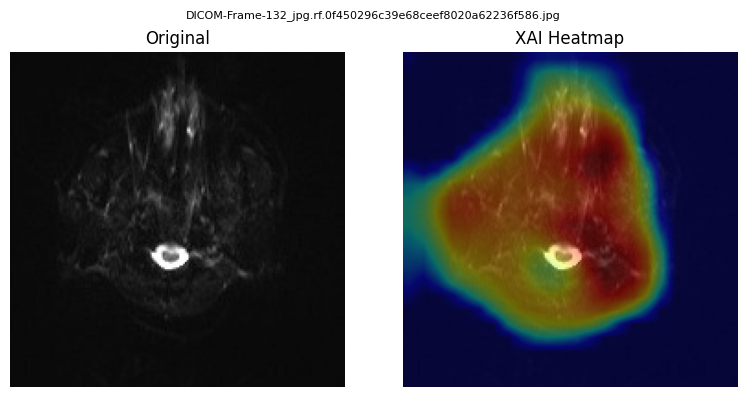

Explaining: DICOM-Frame-182_jpg.rf.88f0ce81fd27fbdee357c356dee5c4d7.jpg


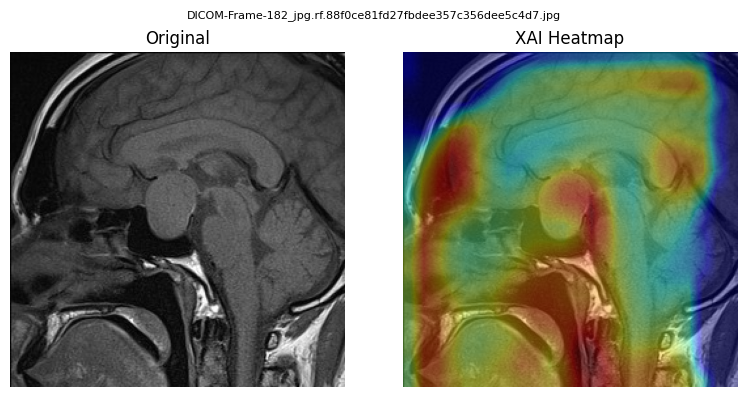

Explaining: DICOM-Frame-222_jpg.rf.23b2ec354c57b816a2503f87b0ba20ae.jpg


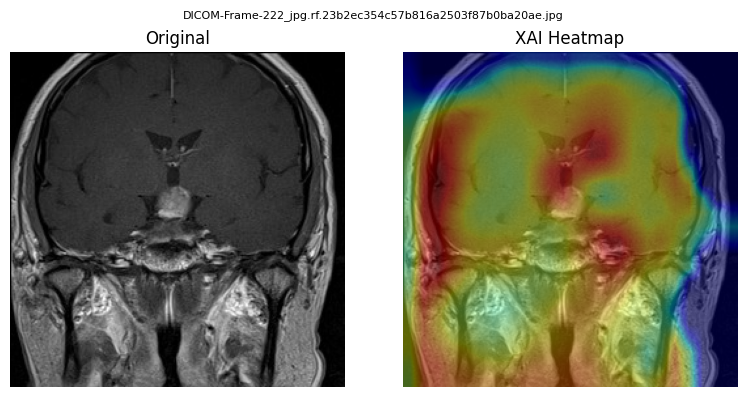

Explaining: DICOM-Frame-242_jpg.rf.0d8a43fb62bdb46dbf25f5aa3e442200.jpg


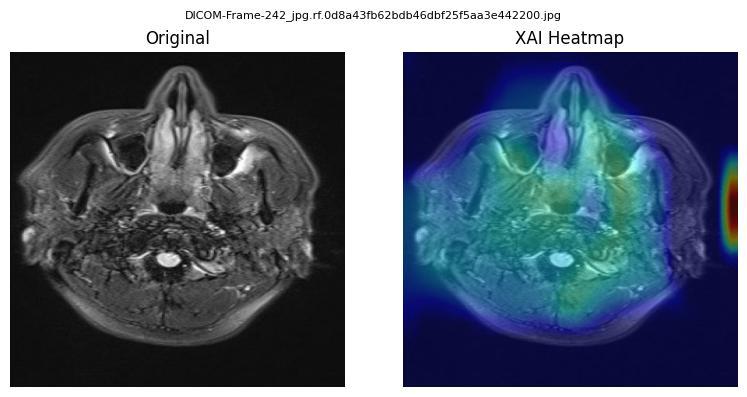

Explaining: DICOM-Frame-96_jpg.rf.67ce1570834babf6503fd81b4e7ffdae.jpg


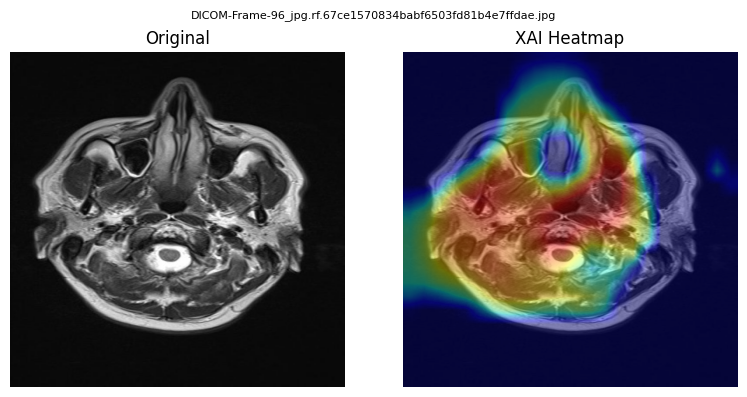

Explaining: Te-gl_0028_jpg.rf.aceec18d7f77be59a0803fb8df38bf67.jpg


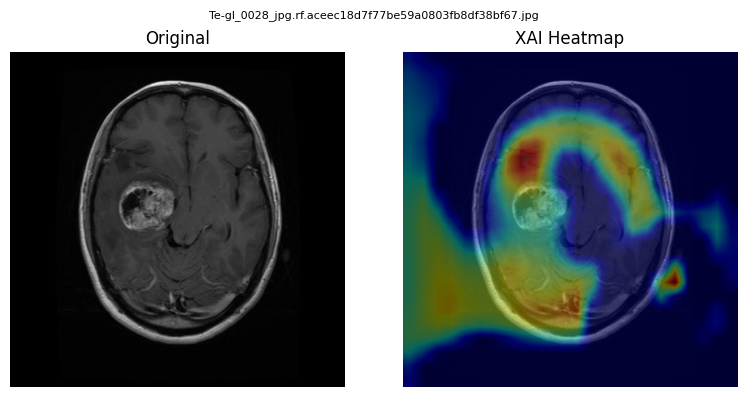

In [29]:
for img_path in test_images[:6]:   # explain first 6 images
    print("Explaining:", img_path.name)
    
    bgr = cv2.imread(str(img_path))
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    # Run YOLO to trigger hook
    _ = model(str(img_path), verbose=False)

    act = feature_maps.get("value", None)
    if act is None:
        print("No activation captured, skipping.")
        continue

    act = act[0]
    heat = act.mean(dim=0).cpu().numpy()
    heat = np.maximum(heat, 0)
    heat -= heat.min()
    if heat.max() > 0:
        heat /= heat.max()

    H, W, _ = rgb.shape
    heat_resized = cv2.resize(heat, (W, H))

    plt.figure(figsize=(8, 4))
    plt.suptitle(img_path.name, fontsize=8)

    plt.subplot(1, 2, 1)
    plt.imshow(rgb); plt.axis("off"); plt.title("Original")

    plt.subplot(1, 2, 2)
    plt.imshow(rgb)
    plt.imshow(heat_resized, cmap="jet", alpha=0.4)
    plt.axis("off"); plt.title("XAI Heatmap")

    plt.tight_layout()
    plt.show()


In [30]:
import pandas as pd

results_path = "/kaggle/working/runs/segment/brain_seg_yolov8/results.csv"

df = pd.read_csv(results_path)

print(df.head())


   epoch     time  train/box_loss  train/seg_loss  train/cls_loss  \
0      1  136.899         1.02949         1.56681         1.94706   
1      2  280.983         1.09021         1.51766         1.08350   
2      3  425.145         1.07199         1.52434         1.00749   
3      4  568.907         1.06417         1.47273         0.93079   
4      5  712.419         1.04016         1.42445         0.85966   

   train/dfl_loss  metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
0         1.22502               0.55611            0.50967           0.56919   
1         1.25347               0.70841            0.72226           0.76873   
2         1.26248               0.75700            0.70625           0.78717   
3         1.24228               0.81398            0.79528           0.85144   
4         1.22844               0.87010            0.83281           0.88983   

   metrics/mAP50-95(B)  ...  metrics/recall(M)  metrics/mAP50(M)  \
0              0.37459  ...         

In [31]:
# show all columns
print(df.columns)

# take last epoch
last = df.iloc[-1]

precision = last.get("metrics/precision(B)")
recall    = last.get("metrics/recall(B)")
f1        = last.get("metrics/f1(B)")

print("Precision (P):", precision)
print("Sensitivity (S):", recall)
print("F1-score (F):", f1)


Index(['epoch', 'time', 'train/box_loss', 'train/seg_loss', 'train/cls_loss',
       'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)',
       'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'metrics/precision(M)',
       'metrics/recall(M)', 'metrics/mAP50(M)', 'metrics/mAP50-95(M)',
       'val/box_loss', 'val/seg_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')
Precision (P): 0.93556
Sensitivity (S): 0.94078
F1-score (F): None


Device: cuda

=== Global FSP (overall, from results.csv) ===
Precision (P):   0.9356
Sensitivity (S): 0.9408
F1-score (F):    0.9382

Running model.val(...) to get per-class metrics (may take some time)...
Ultralytics 8.3.246 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8s-seg summary (fused): 85 layers, 11,780,761 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 3.1±5.8 ms, read: 91.4±22.4 MB/s, size: 37.8 KB)
val: Scanning /kaggle/input/yolov8-segmentation/test/labels... 179 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 179/179 421.5it/s 0.4s
WARNING ⚠️ val: Cache directory /kaggle/input/yolov8-segmentation/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 2.0it/s 6.1s
                   all        179        178      0.966      0.961      0.973      0.784      0.966      0.961      0.973   

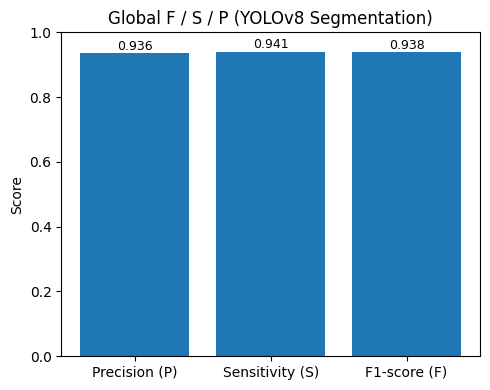


Using last Conv2d layer for XAI: Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
Explaining image: DICOM-Frame-132_jpg.rf.0f450296c39e68ceef8020a62236f586.jpg
Activation shape: torch.Size([32, 24, 24])


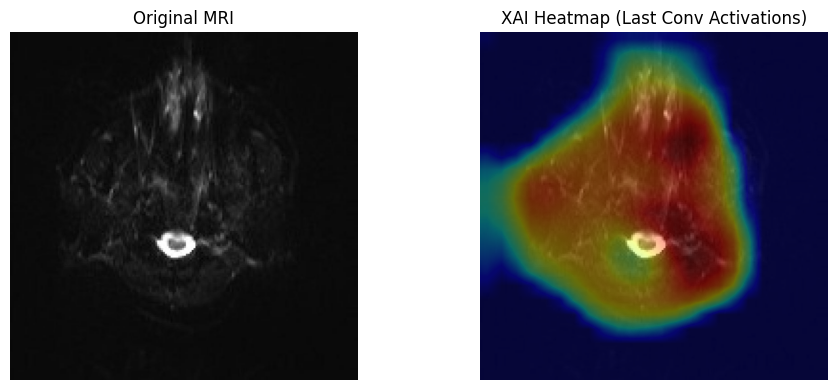

In [32]:
# XAI + FSP + per-class metrics + bar plot in one cell

from pathlib import Path
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# -----------------------------
# 1) Paths and basic setup
# -----------------------------
WEIGHTS = Path("/kaggle/working/runs/segment/brain_seg_yolov8/weights/best.pt")
RESULTS_CSV = Path("/kaggle/working/runs/segment/brain_seg_yolov8/results.csv")
DATA_YAML = "/kaggle/input/yolov8-segmentation/data.yaml"
TEST_IMG_DIR = Path("/kaggle/input/yolov8-segmentation/test/images")

assert WEIGHTS.exists(), f"Weights not found: {WEIGHTS}"
assert RESULTS_CSV.exists(), f"results.csv not found: {RESULTS_CSV}"
assert TEST_IMG_DIR.exists(), f"Test image dir not found: {TEST_IMG_DIR}"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# -----------------------------
# 2) Global F, S, P from results.csv
# -----------------------------
df = pd.read_csv(RESULTS_CSV)
last = df.iloc[-1]  # last epoch

P_global = float(last["metrics/precision(B)"])  # Precision (boxes)
S_global = float(last["metrics/recall(B)"])     # Recall/Sensitivity (boxes)
F_global = 2 * P_global * S_global / (P_global + S_global) if (P_global + S_global) > 0 else 0.0

print("\n=== Global FSP (overall, from results.csv) ===")
print(f"Precision (P):   {P_global:.4f}")
print(f"Sensitivity (S): {S_global:.4f}")
print(f"F1-score (F):    {F_global:.4f}")

# -----------------------------
# 3) Per-class F, S, P from model.val()
# -----------------------------
print("\nRunning model.val(...) to get per-class metrics (may take some time)...")
model = YOLO(str(WEIGHTS))
metrics = model.val(data=DATA_YAML, split="test", verbose=False)  # if split='test' fails, change to 'val'

names = model.names  # dict: class_id -> class_name
per_class_rows = []

# According to Ultralytics metrics docs, SegmentMetrics.class_result(i)
# returns [p_box, r_box, ap50_box, ap_box, p_mask, r_mask, ap50_mask, ap_mask]
# We use the mask precision/recall for segmentation.
for cid, cname in names.items():
    cr = metrics.class_result(cid)  # list of floats
    # Fallback: if seg metrics not there for some reason, use box p/r
    if len(cr) >= 6:
        p_mask, r_mask = float(cr[4]), float(cr[5])
        ap50_m, ap_m = float(cr[6]), float(cr[7])
    else:
        p_mask, r_mask = float(cr[0]), float(cr[1])
        ap50_m, ap_m = float(cr[2]), float(cr[3])

    F_mask = 2 * p_mask * r_mask / (p_mask + r_mask) if (p_mask + r_mask) > 0 else 0.0

    per_class_rows.append(
        dict(
            class_id=cid,
            class_name=cname,
            precision=p_mask,
            sensitivity=r_mask,
            f1=F_mask,
            map50=ap50_m,
            map=ap_m,
        )
    )

df_classes = pd.DataFrame(per_class_rows)
print("\n=== Per-class FSP (mask-based) ===")
print(df_classes[["class_id", "class_name", "precision", "sensitivity", "f1"]])

# -----------------------------
# 4) Plot global F / S / P bar chart
# -----------------------------
plt.figure(figsize=(5, 4))
metrics_names = ["Precision (P)", "Sensitivity (S)", "F1-score (F)"]
metric_values = [P_global, S_global, F_global]

plt.bar(metrics_names, metric_values)
plt.ylim(0, 1.0)
for i, v in enumerate(metric_values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
plt.ylabel("Score")
plt.title("Global F / S / P (YOLOv8 Segmentation)")
plt.tight_layout()
plt.show()

# -----------------------------
# 5) Simple XAI: last Conv activation heatmap on one test MRI
# -----------------------------
# Load inner YOLO model
inner_model = model.model.to(device)
inner_model.eval()

# Find last Conv2d layer
conv_layers = [m for m in inner_model.modules() if isinstance(m, nn.Conv2d)]
assert conv_layers, "No Conv2d layers found in YOLO model."
last_conv = conv_layers[-1]
print("\nUsing last Conv2d layer for XAI:", last_conv)

# Hook to capture feature maps
feature_maps = {}

def hook_fn(module, input, output):
    feature_maps["value"] = output.detach()

hook_handle = last_conv.register_forward_hook(hook_fn)

# Pick one test image
test_images = sorted(TEST_IMG_DIR.glob("*.jpg"))
assert test_images, f"No .jpg images found in {TEST_IMG_DIR}"
img_path = test_images[0]
print("Explaining image:", img_path.name)

# Read image (BGR -> RGB)
bgr = cv2.imread(str(img_path))
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

# Run YOLO prediction (this triggers the hook)
_ = model(str(img_path), verbose=False)

# Get feature map from hooked layer
act = feature_maps.get("value", None)
assert act is not None, "Hook did not capture any activations."

# Use first item in batch: shape [C, H, W]
act = act[0]  # tensor
print("Activation shape:", act.shape)

# Build heatmap: mean across channels -> [H, W]
heat = act.mean(dim=0).cpu().numpy()
heat = np.maximum(heat, 0)
heat -= heat.min()
if heat.max() > 0:
    heat /= heat.max()

# Resize heatmap to image size
H, W, _ = rgb.shape
heat_resized = cv2.resize(heat, (W, H))

# Visualize original vs heatmap overlay
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title("Original MRI")
plt.imshow(rgb)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("XAI Heatmap (Last Conv Activations)")
plt.imshow(rgb)
plt.imshow(heat_resized, cmap="jet", alpha=0.4)
plt.axis("off")

plt.tight_layout()
plt.show()

# Remove hook to avoid side effects later
hook_handle.remove()


In [33]:
from pathlib import Path
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import shutil
import os

# -----------------------------
# Paths
# -----------------------------
RUN_DIR = Path("/kaggle/working/runs/segment/brain_seg_yolov8")
WEIGHTS = RUN_DIR / "weights/best.pt"
RESULTS_CSV = RUN_DIR / "results.csv"
DATA_YAML = "/kaggle/input/yolov8-segmentation/data.yaml"
TEST_IMG_DIR = Path("/kaggle/input/yolov8-segmentation/test/images")
RESULTS_DIR = Path("/kaggle/working/results")

assert WEIGHTS.exists(), f"Weights not found: {WEIGHTS}"
assert RESULTS_CSV.exists(), f"results.csv not found: {RESULTS_CSV}"
assert TEST_IMG_DIR.exists(), f"Test image dir not found: {TEST_IMG_DIR}"

RESULTS_DIR.mkdir(exist_ok=True, parents=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# -----------------------------
# Global F, S, P from results.csv
# -----------------------------
df = pd.read_csv(RESULTS_CSV)
last = df.iloc[-1]  # last epoch

P_global = float(last["metrics/precision(B)"])  # precision
S_global = float(last["metrics/recall(B)"])     # sensitivity/recall
F_global = 2 * P_global * S_global / (P_global + S_global) if (P_global + S_global) > 0 else 0.0

print("\n=== Global FSP (from results.csv) ===")
print(f"Precision (P):   {P_global:.4f}")
print(f"Sensitivity (S): {S_global:.4f}")
print(f"F1-score (F):    {F_global:.4f}")

# -----------------------------
# Per-class F, S, P from model.val()
# -----------------------------
print("\nRunning model.val(...) to get per-class metrics (may take some time)...")
model = YOLO(str(WEIGHTS))
metrics = model.val(data=DATA_YAML, split="test", verbose=False)  # if split=test fails, change to split='val'

names = model.names  # dict: class_id -> class_name
per_class_rows = []

# NOTE: structure of class_result() can vary; this is my *best-informed* guess
# If it errors, print(metrics.class_result(0)) and adjust indices.
for cid, cname in names.items():
    cr = metrics.class_result(cid)  # list of floats
    # Typical order: [p_box, r_box, ap50_box, ap_box, p_mask, r_mask, ap50_mask, ap_mask]
    if len(cr) >= 6:
        p_mask, r_mask = float(cr[4]), float(cr[5])
        ap50_m = float(cr[6]) if len(cr) > 6 else np.nan
        ap_m   = float(cr[7]) if len(cr) > 7 else np.nan
    else:
        # fallback: use box metrics if seg not present
        p_mask, r_mask = float(cr[0]), float(cr[1])
        ap50_m = float(cr[2]) if len(cr) > 2 else np.nan
        ap_m   = float(cr[3]) if len(cr) > 3 else np.nan

    F_mask = 2 * p_mask * r_mask / (p_mask + r_mask) if (p_mask + r_mask) > 0 else 0.0

    per_class_rows.append(
        dict(
            class_id=cid,
            class_name=cname,
            precision=p_mask,
            sensitivity=r_mask,
            f1=F_mask,
            map50=ap50_m,
            map=ap_m,
        )
    )

df_classes = pd.DataFrame(per_class_rows)
print("\n=== Per-class FSP (mask-based) ===")
print(df_classes[["class_id", "class_name", "precision", "sensitivity", "f1"]])

# Save per-class metrics to results folder
df_classes.to_csv(RESULTS_DIR / "per_class_fsp.csv", index=False)
print(f"\nSaved per-class FSP to {RESULTS_DIR/'per_class_fsp.csv'}")


Device: cuda

=== Global FSP (from results.csv) ===
Precision (P):   0.9356
Sensitivity (S): 0.9408
F1-score (F):    0.9382

Running model.val(...) to get per-class metrics (may take some time)...
Ultralytics 8.3.246 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8s-seg summary (fused): 85 layers, 11,780,761 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 61.9±11.9 MB/s, size: 34.3 KB)
val: Scanning /kaggle/input/yolov8-segmentation/test/labels... 179 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 179/179 716.8it/s 0.2s
WARNING ⚠️ val: Cache directory /kaggle/input/yolov8-segmentation/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 1.9it/s 6.3s
                   all        179        178      0.966      0.961      0.973      0.784      0.966      0.961      0.973      0.796


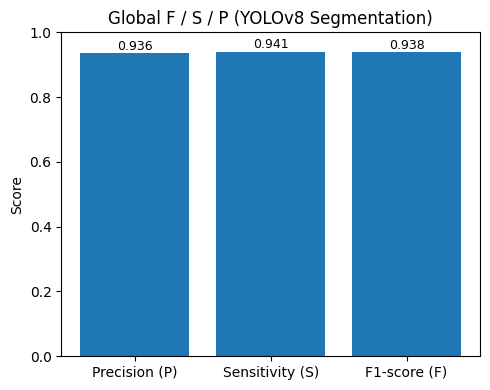

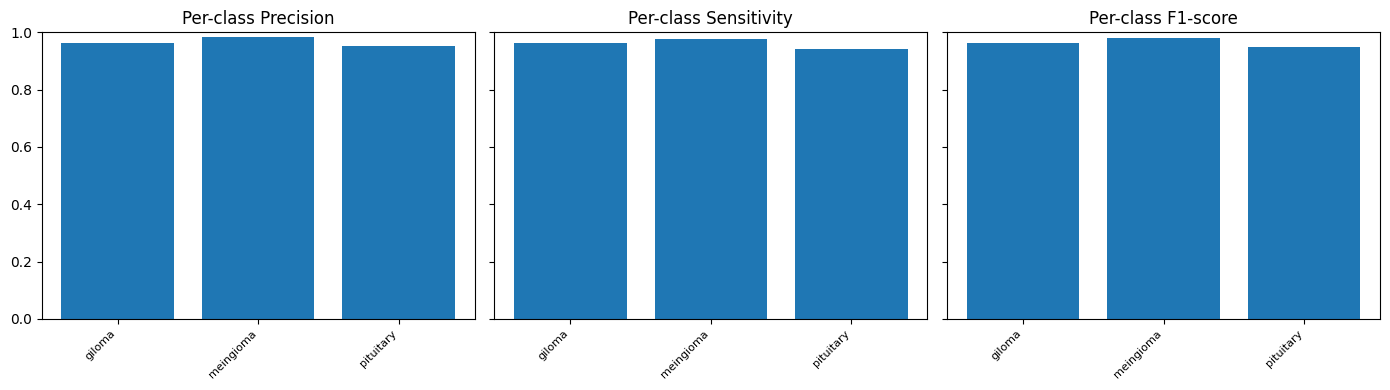

In [34]:
# -----------------------------
# Global F / S / P bar chart
# -----------------------------
plt.figure(figsize=(5, 4))
metrics_names = ["Precision (P)", "Sensitivity (S)", "F1-score (F)"]
metric_values = [P_global, S_global, F_global]

plt.bar(metrics_names, metric_values)
plt.ylim(0, 1.0)
for i, v in enumerate(metric_values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
plt.ylabel("Score")
plt.title("Global F / S / P (YOLOv8 Segmentation)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "global_fsp_bar.png", dpi=300)
plt.show()

# -----------------------------
# Per-class F / S / P bar charts
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

x = np.arange(len(df_classes))
labels = df_classes["class_name"].tolist()

axes[0].bar(x, df_classes["precision"])
axes[0].set_title("Per-class Precision")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45, ha="right", fontsize=8)

axes[1].bar(x, df_classes["sensitivity"])
axes[1].set_title("Per-class Sensitivity")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45, ha="right", fontsize=8)

axes[2].bar(x, df_classes["f1"])
axes[2].set_title("Per-class F1-score")
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, rotation=45, ha="right", fontsize=8)

for ax in axes:
    ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "per_class_fsp_bar.png", dpi=300)
plt.show()


Using last Conv2d layer for XAI: Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
Explaining image: DICOM-Frame-132_jpg.rf.0f450296c39e68ceef8020a62236f586.jpg
Activation shape: torch.Size([32, 24, 24])


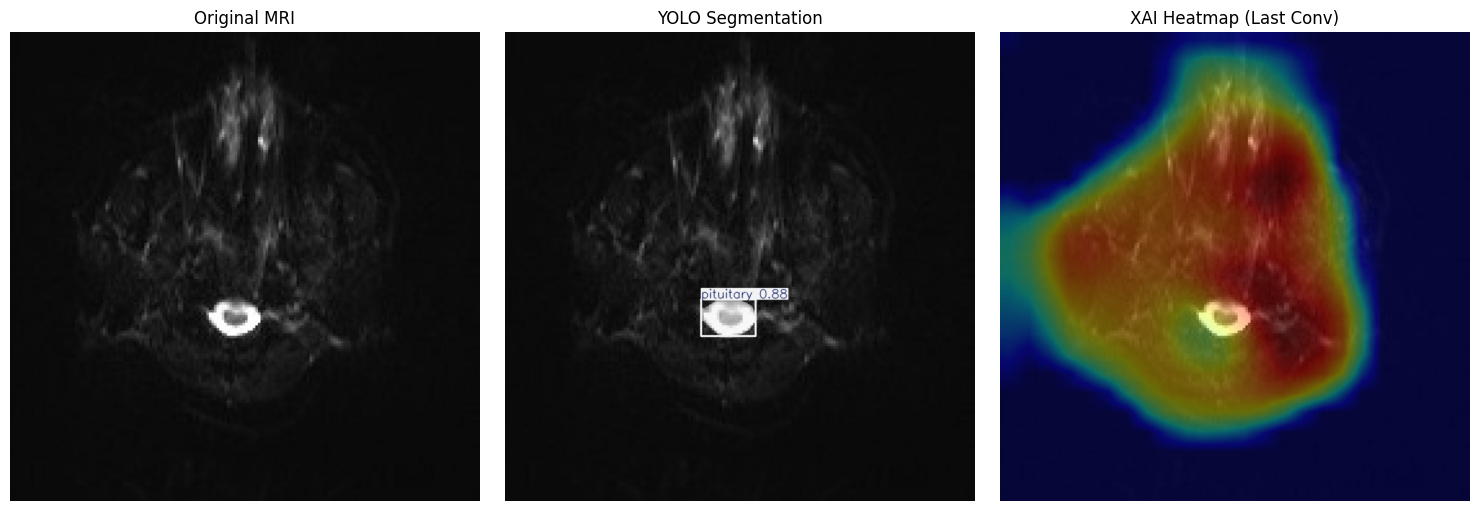

In [35]:
# -----------------------------
# Simple XAI: last Conv activation heatmap
# + side-by-side: Original / YOLO seg / Heatmap
# -----------------------------

inner_model = model.model.to(device)
inner_model.eval()

# Find last Conv2d
conv_layers = [m for m in inner_model.modules() if isinstance(m, nn.Conv2d)]
assert conv_layers, "No Conv2d layers found in YOLO model."
last_conv = conv_layers[-1]
print("Using last Conv2d layer for XAI:", last_conv)

feature_maps = {}

def hook_fn(module, input, output):
    feature_maps["value"] = output.detach()

hook_handle = last_conv.register_forward_hook(hook_fn)

# Pick one test image
test_images = sorted(TEST_IMG_DIR.glob("*.jpg"))
assert test_images, f"No .jpg images found in {TEST_IMG_DIR}"
img_path = test_images[0]
print("Explaining image:", img_path.name)

# Read image
bgr = cv2.imread(str(img_path))
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

# YOLO segmentation prediction
results = model(str(img_path), verbose=False)
seg_vis_bgr = results[0].plot()   # BGR with masks/boxes drawn
seg_vis_rgb = cv2.cvtColor(seg_vis_bgr, cv2.COLOR_BGR2RGB)

# Get activation from hook
act = feature_maps.get("value", None)
assert act is not None, "Hook did not capture any activations."
act = act[0]  # [C, H, W]
print("Activation shape:", act.shape)

# Build heatmap
heat = act.mean(dim=0).cpu().numpy()
heat = np.maximum(heat, 0)
heat -= heat.min()
if heat.max() > 0:
    heat /= heat.max()

H, W, _ = rgb.shape
heat_resized = cv2.resize(heat, (W, H))

# Save and show side-by-side figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb)
axes[0].set_title("Original MRI")
axes[0].axis("off")

axes[1].imshow(seg_vis_rgb)
axes[1].set_title("YOLO Segmentation")
axes[1].axis("off")

axes[2].imshow(rgb)
axes[2].imshow(heat_resized, cmap="jet", alpha=0.4)
axes[2].set_title("XAI Heatmap (Last Conv)")
axes[2].axis("off")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "side_by_side_xai.png", dpi=300)
plt.show()

hook_handle.remove()


Copied: confusion_matrix.png
Copied: confusion_matrix_normalized.png


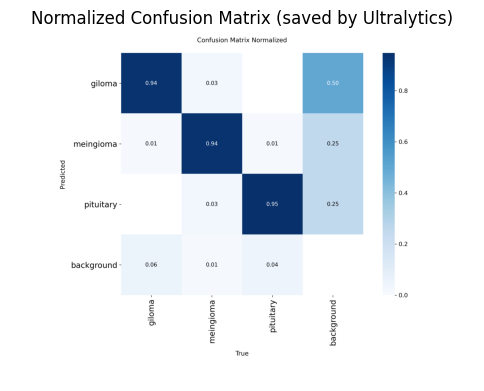

In [36]:
cm_src = RUN_DIR / "confusion_matrix.png"
cmn_src = RUN_DIR / "confusion_matrix_normalized.png"

for src in [cm_src, cmn_src]:
    if src.exists():
        shutil.copy(src, RESULTS_DIR / src.name)
        print("Copied:", src.name)

# Show normalized confusion matrix if present
if cmn_src.exists():
    img = plt.imread(str(RESULTS_DIR / "confusion_matrix_normalized.png"))
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Normalized Confusion Matrix (saved by Ultralytics)")
    plt.show()
else:
    print("Normalized confusion matrix not found in run directory.")


In [37]:
from matplotlib.backends.backend_pdf import PdfPages

pdf_path = RESULTS_DIR / "report.pdf"
print("Creating PDF report at:", pdf_path)

with PdfPages(pdf_path) as pdf:

    # Page 1: Text & global metrics
    fig, ax = plt.subplots(figsize=(8.27, 11.69))  # A4 portrait
    ax.axis("off")
    ax.text(0.5, 0.9, "Brain Tumor Segmentation – YOLOv8 Report", ha="center", fontsize=16, weight="bold")
    ax.text(0.0, 0.8, "Global Metrics (FSP):", fontsize=12, weight="bold")
    ax.text(0.05, 0.75, f"Precision (P):   {P_global:.4f}", fontsize=11)
    ax.text(0.05, 0.72, f"Sensitivity (S): {S_global:.4f}", fontsize=11)
    ax.text(0.05, 0.69, f"F1-score (F):    {F_global:.4f}", fontsize=11)

    ax.text(0.0, 0.62, "Per-class FSP (mask-based):", fontsize=12, weight="bold")

    # small table
    table_data = [["Class", "Precision", "Sensitivity", "F1-score"]]
    for _, row in df_classes.iterrows():
        table_data.append([
            str(row["class_name"]),
            f"{row['precision']:.3f}",
            f"{row['sensitivity']:.3f}",
            f"{row['f1']:.3f}",
        ])
    table = ax.table(cellText=table_data, colLabels=None, loc="upper left", colWidths=[0.2, 0.2, 0.2, 0.2])
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.2)

    pdf.savefig(fig)
    plt.close(fig)

    # Page 2: Global FSP bar plot
    img = plt.imread(RESULTS_DIR / "global_fsp_bar.png")
    fig, ax = plt.subplots(figsize=(8.27, 11.69))
    ax.imshow(img)
    ax.axis("off")
    pdf.savefig(fig)
    plt.close(fig)

    # Page 3: Per-class FSP bar plots
    img = plt.imread(RESULTS_DIR / "per_class_fsp_bar.png")
    fig, ax = plt.subplots(figsize=(8.27, 11.69))
    ax.imshow(img)
    ax.axis("off")
    pdf.savefig(fig)
    plt.close(fig)

    # Page 4: Side-by-side XAI
    xai_img_path = RESULTS_DIR / "side_by_side_xai.png"
    if xai_img_path.exists():
        img = plt.imread(xai_img_path)
        fig, ax = plt.subplots(figsize=(8.27, 11.69))
        ax.imshow(img)
        ax.axis("off")
        pdf.savefig(fig)
        plt.close(fig)

    # Page 5: Confusion matrix (if available)
    cmn_path = RESULTS_DIR / "confusion_matrix_normalized.png"
    if cmn_path.exists():
        img = plt.imread(cmn_path)
        fig, ax = plt.subplots(figsize=(8.27, 11.69))
        ax.imshow(img)
        ax.axis("off")
        pdf.savefig(fig)
        plt.close(fig)

print("PDF report created.")


Creating PDF report at: /kaggle/working/results/report.pdf
PDF report created.


In [38]:
!pip install python-pptx


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 14.1 MB/s eta 0:00:00


In [39]:
from pptx import Presentation
from pptx.util import Inches, Pt

ppt_path = RESULTS_DIR / "report_slides.pptx"
prs = Presentation()

# Slide 1: Title + global metrics
slide_layout = prs.slide_layouts[0]  # title slide
slide = prs.slides.add_slide(slide_layout)
slide.shapes.title.text = "Brain Tumor Segmentation – YOLOv8"
subtitle = slide.placeholders[1]
subtitle.text = (
    f"Precision (P): {P_global:.4f}\n"
    f"Sensitivity (S): {S_global:.4f}\n"
    f"F1-score (F): {F_global:.4f}"
)

# Slide 2: Global FSP bar chart
slide_layout = prs.slide_layouts[5]  # title only
slide = prs.slides.add_slide(slide_layout)
slide.shapes.title.text = "Global F / S / P"
left = Inches(1)
top = Inches(1.5)
pic = slide.shapes.add_picture(str(RESULTS_DIR / "global_fsp_bar.png"), left, top, width=Inches(8))

# Slide 3: Per-class bar chart
slide = prs.slides.add_slide(slide_layout)
slide.shapes.title.text = "Per-class F / S / P"
pic = slide.shapes.add_picture(str(RESULTS_DIR / "per_class_fsp_bar.png"), left, top, width=Inches(8))

# Slide 4: XAI side-by-side
xai_img_path = RESULTS_DIR / "side_by_side_xai.png"
if xai_img_path.exists():
    slide = prs.slides.add_slide(slide_layout)
    slide.shapes.title.text = "Side-by-side: Original / YOLO / XAI"
    pic = slide.shapes.add_picture(str(xai_img_path), left, top, width=Inches(8))

# Slide 5: Confusion matrix (if available)
cmn_path = RESULTS_DIR / "confusion_matrix_normalized.png"
if cmn_path.exists():
    slide = prs.slides.add_slide(slide_layout)
    slide.shapes.title.text = "Normalized Confusion Matrix"
    pic = slide.shapes.add_picture(str(cmn_path), left, top, width=Inches(8))

prs.save(str(ppt_path))
print("PowerPoint saved at:", ppt_path)


PowerPoint saved at: /kaggle/working/results/report_slides.pptx


In [40]:
# =============================
# YOLOv8-Seg Architecture Diagram (Graphviz)
# =============================

from graphviz import Digraph

dot = Digraph("YOLOv8-Seg", format="png")
dot.attr(rankdir="LR", size="12,6")

# --- Nodes ---
dot.node("input", "Input MRI\n+ Preprocessing", shape="box", style="filled", fillcolor="#E0E0E0")

dot.node("backbone", "Backbone\nEfficientRep + C2f + SPPF\nOutputs: P3, P4, P5", 
         shape="box", style="filled", fillcolor="#AED6F1")

dot.node("neck", "Neck (FPN + PAN)\nOutputs: F3, F4, F5", 
         shape="box", style="filled", fillcolor="#F9E79F")

dot.node("detect", "Detection Head\n(Objectness, Class, Box Regression)", 
         shape="box", style="filled", fillcolor="#ABEBC6")

dot.node("segment", "Segmentation Head\n(K Prototypes + Mask Coefficients)", 
         shape="box", style="filled", fillcolor="#D7BDE2")

dot.node("boxes", "Final Bounding Boxes\n+ Tumor Labels", shape="box")
dot.node("masks", "Final Instance Masks\n(Segmentation)", shape="box")

# --- Edges ---
dot.edge("input", "backbone")
dot.edge("backbone", "neck")
dot.edge("neck", "detect")
dot.edge("neck", "segment")

dot.edge("detect", "boxes")
dot.edge("segment", "masks")

# Render
output_path = "/mnt/data/YOLOv8-Seg_Diagram"
dot.render(output_path, cleanup=True)

output_path + ".png"


'/mnt/data/YOLOv8-Seg_Diagram.png'